## Create function that loads in one 8-day average of MODIS data and plots chla in our study region

In [53]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy
import matplotlib.path as mpath

from importlib import reload
import SO_tools as tools; reload(tools)

<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

## Reading in .csv and adding season/datetime

In [54]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
# df_new = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv') # for stevie


/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_5704/3417850893.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')


In [55]:
# NEW DATA

#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed',utc=True)
df_new = df_new.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon 

#fix lat lon values with '--' (replace with nan) 
df_new['LATITUDE'] = pd.to_numeric(df_new['LATITUDE'], errors='coerce')
df_new['LONGITUDE'] = pd.to_numeric(df_new['LONGITUDE'], errors='coerce')


In [56]:
#create season columns
df_new["year"] = df_new["DATE"].dt.year.astype("Int64")
df_new["month"] = df_new["DATE"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

df_new["season"] = df_new.apply(assign_season, axis=1)

## Login to earthaccess

In [57]:
auth = earthaccess.login()

## Workshopping

Search for data, stream the files and plot each one with float trajectories in for loop

In [9]:
# Find datasets related to the VIIRS satellite mission
datasets = earthaccess.search_datasets(instrument="VIIRS")

# Print the short names of the found datasets
for dataset in datasets:
    print(dataset.summary())

{'short-name': 'CIESIN_SEDAC_USPAT_USUEXT2015', 'concept-id': 'C3550194034-ESDIS', 'version': '1.0', 'file-type': "[{'Format': 'GeoTIFF', 'Fees': '0'}, {'Format': 'PDF', 'Fees': '0'}, {'Format': 'PNG', 'Fees': '0'}, {'Format': 'WMS', 'Fees': '0'}]", 'get-data': ['https://search.earthdata.nasa.gov/search/granules?p=C3550194034-ESDIS']}
{'short-name': 'gov.noaa.nodc:0209226', 'concept-id': 'C2089378705-NOAA_NCEI', 'version': 'Not Applicable', 'file-type': '', 'get-data': ['https://www.ncei.noaa.gov/archive/accession/0209226', 'https://www.ncei.noaa.gov/archive/accession/oas/209226', 'https://www.ncei.noaa.gov/archive/accession/download/209226', 'ftp://ftp-oceans.ncei.noaa.gov/nodc/archive/arc0155/0209226/']}
{'short-name': 'ALAN_VIIRS_CONUS', 'concept-id': 'C2650219940-GES_DISC', 'version': '1', 'file-type': '', 'get-data': ['https://acdisc.gesdisc.eosdis.nasa.gov/data/HAQAST/ALAN_VIIRS_CONUS.1/', 'https://search.earthdata.nasa.gov/search/granules?p=C2650219940-GES_DISC'], 'cloud-info': 

/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_21897/3003824565.py:6: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(dataset.summary())
/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_21897/3003824565.py:6: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(dataset.summary())
/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_21897/3003824565.py:6: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(dataset.summary())
/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_21897/3003824565.py:6: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `Da

## Final Function

In [24]:
# version edited by Lilah on 8/13/26
def chla_plot_matchups(shortname, tspan, bbox, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        bounding_box=bbox,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(130, 180), lat=slice(-55,-70))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)

        # BGC FLOAT DATA --------------------------------
        # subset the Argo profile data
        df_sub = df_new[(df_new["LATITUDE"]<=-55) & (df_new["LATITUDE"]>=-70) & (df_new["LONGITUDE"]>=130) & (df_new["LONGITUDE"]<=180)]
        df_subset = df_sub[(df_sub["DATE"] >= time_start) & (df_sub["DATE"] <= time_end)]
        # extract nearest surface chla point
        df_chla = (df_subset.dropna(subset=['CHLA_ADJUSTED']).sort_values(['WMOID','CYCLE_NUMBER','PRES_ADJUSTED']).groupby(['WMOID','CYCLE_NUMBER']).first().reset_index())

        # extract WMOIDs for this time period
        wmoids = df_chla['WMOID'].unique()
        # create a colormap for the WMOID legend
        cmap = plt.get_cmap('gist_rainbow', len(wmoids))
        wmoid_colors = {wmo: cmap(i) for i, wmo in enumerate(wmoids)}

        # CORE FLOAT DATA --------------------------------
        # subset the Argo profile data
        df_sub = df_new[(df_new["LATITUDE"]<=-55) & (df_new["LATITUDE"]>=-70) & (df_new["LONGITUDE"]>=130) & (df_new["LONGITUDE"]<=180)]
        df_subset = df_sub[(df_sub["DATE"] >= time_start) & (df_sub["DATE"] <= time_end)]
        # extract nearest surface chla point
        df_chla = (df_subset.dropna(subset=['CHLA_ADJUSTED']).sort_values(['WMOID','CYCLE_NUMBER','PRES_ADJUSTED']).groupby(['WMOID','CYCLE_NUMBER']).first().reset_index())

        # extract WMOIDs for this time period
        wmoids = df_chla['WMOID'].unique()
        # create a colormap for the WMOID legend
        cmap = plt.get_cmap('gist_rainbow', len(wmoids))
        wmoid_colors = {wmo: cmap(i) for i, wmo in enumerate(wmoids)}
        
        
        # PLOTTING DATA ------------------------------------------------
        
        #assign projection type
        crs0 = ccrs.PlateCarree()
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        #colorscale range (same for Argo and satellite)
        norm = LogNorm(vmin=0.1, vmax=6)
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs0,norm=norm) 

        #chla colorbar
        cbar = fig.colorbar(plot, fraction=0.02, pad=0.03)
        cbar.set_label('Log Chl-a (mg m$^{-3}$)')
        cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        
        # plot points for each WMOID - point color = chla, edgecolor = WMOID
        for wmo in wmoids:
            df_wmo = df_chla[df_chla['WMOID'] == wmo]
        
            sc = ax.scatter(df_wmo['LONGITUDE'],df_wmo['LATITUDE'],c=df_wmo['CHLA_ADJUSTED'],cmap=color,norm=norm,
                       s=150,transform=ccrs.PlateCarree(),edgecolor=wmoid_colors[wmo],linewidth=1,label=str(wmo))
        
        #create legend info
        handles = [
            mlines.Line2D([], [], color=wmoid_colors[wmo], marker='o', linestyle='None', markersize=10, label=str(wmo))
            for wmo in wmoids]

        if len(wmoids) == 0:
            print('no floats')
        else:
            # create legend
            ax.legend(handles=handles,title="WMOID",loc='lower center',ncol=len(wmoids),
                bbox_to_anchor=(0.5, -0.15),fontsize=10,title_fontsize=12)

        # plot cycle number labels (optional, it kind of gets in the way
        # for _, row in df_chla.iterrows():
        #     ax.text(row['LONGITUDE'] + 0.2, row['LATITUDE'] + 0.4,   # add an offset to the label marker
        #             str(int(row['CYCLE_NUMBER'])),transform=ccrs.PlateCarree(),fontsize=9,
        #             fontweight='bold', color='white', ha='center')

        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

        # Define start and end points for KR1 and KR2
        start_lon1, start_lat1 = 151.33, -60.24
        end_lon1, end_lat1 = 153.08, -59.89
        start_lon2, start_lat2 = 156.12, -62.91
        end_lon2, end_lat2 = 160.48, -61.66
        
        # Plot diagonal line on map
        ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())
        ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())

        cutoff = pd.Timestamp("2024-12-31", tz="UTC")

        if time_start <= cutoff:            # Adding fronts to plot
            # front_ds = xr.open_dataset('/raid/walkersl/SO_Argo/Data/SO_front_fields_zones_monthly.nc')
            front_ds = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data_Summer/SO_front_fields_zones_monthly.nc')

            front_field_levels = {
                'STF': ('theta_100', 11.0),
                'SAF': ('theta_400', 5.0),
                'PF':  ('theta_min', 2.0),
            }

            def get_front_contours(front_ds, timestep, front_field_levels):
                """Return dict of {front_name: list of (N,2) lon/lat vertex arrays} for one timestep."""
                contours = {}
                for front, (varname, level) in front_field_levels.items():
                    field = front_ds[varname].sel(time=timestep, method='nearest')
                    gen = contourpy.contour_generator(x=field['lon'].values, y=field['lat'].values, z=field.values)
                    contours[front] = gen.lines(level)
                return contours

            time = front_ds['time']
            timestep = time.isel(time=i).values
            timestep = pd.to_datetime(timestep, utc=True)
            time_label = timestep.strftime("%Y-%m-%d")

            front_contours = get_front_contours(front_ds, time_label, front_field_levels)

            front_colors = {'STF': 'green', 'SAF': 'fuchsia', 'PF': 'cyan'}
            for front, lines in front_contours.items():
                for verts in lines:
                    ax.plot(verts[:,0], verts[:,1], color=front_colors[front],
                         transform=ccrs.PlateCarree(), linewidth=1.5)

        ax.set_extent([130, 180, -70, -55])
        
        # create string for the title label
        title_start = time_start.strftime("%Y-%m-%d")
        title_end = time_end.strftime("%Y-%m-%d")
        
        ax.set_title(title_start+' to '+title_end+' '+shortname, fontsize=16)        
        
        #save figure
        # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_{shortname}_float_matchup.png',
        #         bbox_inches='tight')
        fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_{shortname}_float_matchup.png', bbox_inches='tight')
        plt.close()

# 8-day composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-12-30"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.8D.*4*")

# monthly composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-01-31"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.MO.*4*")

# monthly composites with VIIRS
chla_plot_matchups(shortname="VIIRSN_L3m_CHL",
                   tspan=("2025-09-01", "2026-04-30"), 
                   bbox=(130, -78, 180, -50), 
                   clouds=None, 
                   granulename="*.MO.*4*")



/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 1891.78it/s]
PROCESSING TASKS | : 100%|██████████| 8/8 [00:01<00:00,  4.89it/s]
COLLECTING RESULTS | : 100%|██████████| 8/8 [00:00<00:00, 85816.96it/s]
 38%|███▊      | 3/8 [00:17<00:29,  5.93s/it]

no floats


 50%|█████     | 4/8 [00:26<00:27,  6.90s/it]

no floats


100%|██████████| 8/8 [00:46<00:00,  5.86s/it]


## Updated figures for poster

In [45]:
time_start = "2019-11-01"
time_end = "2020-03-30"
df_sub = df_new[df_new['WMOID'].isin([5905103])]

df_subset = df_sub[(df_sub["LATITUDE"]<=-55) & (df_sub["LATITUDE"]>=-70) & (df_sub["LONGITUDE"]>=130) & (df_sub["LONGITUDE"]<=180)]
df_subsubset = df_subset[(df_subset["DATE"] >= time_start) & (df_subset["DATE"] <= time_end)]

df_subsubset

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
3723681,3723681,3723681,5905103,64,A,2019-11-09 23:14:43.002488+00:00,1,-59.428,167.287,1,...,NaN,2019,11,2019-2020,34.107094,3.123048,1027.050120,27.034436,6.023318e-07,48.32
3723682,3723682,3723682,5905103,64,A,2019-11-09 23:14:43.002488+00:00,1,-59.428,167.287,1,...,NaN,2019,11,2019-2020,34.107092,3.121988,1027.054897,27.034531,1.594161e-06,48.32
3723683,3723683,3723683,5905103,64,A,2019-11-09 23:14:43.002488+00:00,1,-59.428,167.287,1,...,NaN,2019,11,2019-2020,34.107089,3.121868,1027.064268,27.034539,1.897930e-06,48.32
3723684,3723684,3723684,5905103,64,A,2019-11-09 23:14:43.002488+00:00,1,-59.428,167.287,1,...,NaN,2019,11,2019-2020,34.105872,3.121206,1027.068981,27.033635,1.887189e-06,48.32
3723685,3723685,3723685,5905103,64,A,2019-11-09 23:14:43.002488+00:00,1,-59.428,167.287,1,...,NaN,2019,11,2019-2020,34.105061,3.120765,1027.072123,27.033032,1.378118e-06,48.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3731968,3731968,3731968,5905103,78,A,2020-03-29 05:17:44.000561+00:00,1,-56.467,177.896,1,...,NaN,2020,3,2019-2020,34.702228,2.504199,1032.662651,27.561641,4.158498e-06,104.54
3731969,3731969,3731969,5905103,78,A,2020-03-29 05:17:44.000561+00:00,1,-56.467,177.896,1,...,NaN,2020,3,2019-2020,34.748922,2.448554,1033.160977,27.603502,4.144161e-06,104.54
3731970,3731970,3731970,5905103,78,A,2020-03-29 05:17:44.000561+00:00,1,-56.467,177.896,1,...,NaN,2020,3,2019-2020,34.786343,2.369256,1033.655230,27.639957,6.486245e-06,104.54
3731971,3731971,3731971,5905103,78,A,2020-03-29 05:17:44.000561+00:00,1,-56.467,177.896,1,...,NaN,2020,3,2019-2020,34.822539,2.294490,1034.151577,27.674999,6.477333e-06,104.54


## updated float trajectory for poster

In [ ]:
# version edited by Lilah on 8/13/26
def chla_plot_matchups(shortname, tspan, bbox, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        bounding_box=bbox,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(145, 180), lat=slice(-55,-70))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)

        # BGC FLOAT DATA --------------------------------
        # subset the Argo profile data
        df_sub = df_new[(df_new["LATITUDE"]<=-55) & (df_new["LATITUDE"]>=-70) & (df_new["LONGITUDE"]>=145) & (df_new["LONGITUDE"]<=180)]
        df_subset = df_sub[(df_sub["DATE"] >= time_start) & (df_sub["DATE"] <= time_end)]
        # df_subsubset = df_subset[df_subset['WMOID'].isin([5905379])]
        # extract nearest surface chla point
        # df_chla = (df_subset.dropna(subset=['CHLA_ADJUSTED']).sort_values(['WMOID','CYCLE_NUMBER','PRES_ADJUSTED']).groupby(['WMOID','CYCLE_NUMBER']).first().reset_index())

        # # extract WMOIDs for this time period
        # wmoids = df_subset['WMOID'].unique()
        # # create a colormap for the WMOID legend
        # cmap = plt.get_cmap('gist_rainbow', len(wmoids))
        # wmoid_colors = {wmo: cmap(i) for i, wmo in enumerate(wmoids)}

        # # CORE FLOAT DATA --------------------------------
        # # subset the Argo profile data
        df_sub_2 = df_new[(df_new["LATITUDE"]<=-55) & (df_new["LATITUDE"]>=-70) & (df_new["LONGITUDE"]>=145) & (df_new["LONGITUDE"]<=180)]
        df_subset_2 = df_sub_2[(df_sub_2["DATE"] >= time_start) & (df_sub_2["DATE"] <= time_end)]
        # df_subsubset_2 = df_subset_2[df_subset_2['WMOID'].isin([5905379])]
        # # extract nearest surface chla point
        # df_chla = (df_subset.dropna(subset=['CHLA_ADJUSTED']).sort_values(['WMOID','CYCLE_NUMBER','PRES_ADJUSTED']).groupby(['WMOID','CYCLE_NUMBER']).first().reset_index())

        # # extract WMOIDs for this time period
        # wmoids = df_chla['WMOID'].unique()
        # # create a colormap for the WMOID legend
        # cmap = plt.get_cmap('gist_rainbow', len(wmoids))
        # wmoid_colors = {wmo: cmap(i) for i, wmo in enumerate(wmoids)}
        
        
        # PLOTTING DATA ------------------------------------------------
        
        #assign projection type
        crs0 = ccrs.PlateCarree()
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        #colorscale range (same for Argo and satellite)
        norm = LogNorm(vmin=0.1, vmax=6)
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs0,norm=norm) 
        
        # plot points for each WMOID - point color = chla, edgecolor = WMOID
        # for wmo in wmoids:
        #     df_wmo = df_chla[df_chla['WMOID'] == wmo]
        
        sc = ax.scatter(df_subset['LONGITUDE'],df_subset['LATITUDE'],c=df_subset['MLP'],cmap='spring',
                      s=150,transform=crs0, edgecolors='white', lw=1)

        sc = ax.scatter(df_subset_2['LONGITUDE'],df_subset_2['LATITUDE'],c=df_subset_2['MLP'],cmap='spring',
                      s=150,transform=crs0, edgecolors='white', lw=1)

        

        #chla colorbar
        cbar = fig.colorbar(sc, fraction=0.02, pad=0.08)
        cbar.set_label('Mixed Layer Pressure (m)', fontsize=32)
        # cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        cbar.ax.tick_params(labelsize=26)
        cbar.ax.invert_yaxis()
        
        #create legend info
        # handles = [
        #     mlines.Line2D([], [], color=wmoid_colors[wmo], marker='o', linestyle='None', markersize=10, label=str(wmo))
        #     for wmo in wmoids]

        # if len(wmoids) == 0:
        #     print('no floats')
        # else:
        #     # create legend
        #     ax.legend(handles=handles,title="WMOID",loc='lower center',ncol=len(wmoids),
        #         bbox_to_anchor=(0.5, -0.15),fontsize=10,title_fontsize=12)

        # plot cycle number labels (optional, it kind of gets in the way
        # for _, row in df_chla.iterrows():
        #     ax.text(row['LONGITUDE'] + 0.2, row['LATITUDE'] + 0.4,   # add an offset to the label marker
        #             str(int(row['CYCLE_NUMBER'])),transform=ccrs.PlateCarree(),fontsize=9,
        #             fontweight='bold', color='white', ha='center')

        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

        gl.xlabel_style = {'size': 26, 'color': 'black'}
        gl.ylabel_style = {'size': 26, 'color': 'black'}

        # Define start and end points for KR1 and KR2
        start_lon1, start_lat1 = 151.33, -60.24
        end_lon1, end_lat1 = 153.08, -59.89
        start_lon2, start_lat2 = 156.12, -62.91
        end_lon2, end_lat2 = 160.48, -61.66
        
        # Plot diagonal line on map
        ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())
        ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())

        cutoff = pd.Timestamp("2024-12-31", tz="UTC")

        if time_start <= cutoff:            # Adding fronts to plot
            # front_ds = xr.open_dataset('/raid/walkersl/SO_Argo/Data/SO_front_fields_zones_monthly.nc')
            front_ds = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data_Summer/SO_front_fields_zones_monthly.nc')

            front_field_levels = {
                'STF': ('theta_100', 11.0),
                'SAF': ('theta_400', 5.0),
                'PF':  ('theta_min', 2.0),
            }

            def get_front_contours(front_ds, timestep, front_field_levels):
                """Return dict of {front_name: list of (N,2) lon/lat vertex arrays} for one timestep."""
                contours = {}
                for front, (varname, level) in front_field_levels.items():
                    field = front_ds[varname].sel(time=timestep, method='nearest')
                    gen = contourpy.contour_generator(x=field['lon'].values, y=field['lat'].values, z=field.values)
                    contours[front] = gen.lines(level)
                return contours

            time = front_ds['time']
            timestep = time.isel(time=i).values
            timestep = pd.to_datetime(timestep, utc=True)
            time_label = timestep.strftime("%Y-%m-%d")

            front_contours = get_front_contours(front_ds, time_label, front_field_levels)

            front_colors = {'STF': 'green', 'SAF': 'fuchsia', 'PF': 'cyan'}
            for front, lines in front_contours.items():
                for verts in lines:
                    ax.plot(verts[:,0], verts[:,1], color=front_colors[front],
                         transform=ccrs.PlateCarree(), linewidth=1.5)

        ax.set_extent([145, 180, -70, -55])
        
        
        # create string for the title label
        title_start = time_start.strftime("%Y-%m-%d")
        title_end = time_end.strftime("%Y-%m-%d")
        
        # ax.set_title(title_start+' to '+title_end+' '+shortname, fontsize=16)        
        
        #save figure
        # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_{shortname}_float_matchup.png',
        #         bbox_inches='tight')
        fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/{title_start}_{title_end}_final_fig_traj_mld.png', bbox_inches='tight', dpi=400, transparent=True)
        plt.close()

# 8-day composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-12-30"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.8D.*4*")

# monthly composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-01-31"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.MO.*4*")

# monthly composites with VIIRS
chla_plot_matchups(shortname="VIIRSN_L3m_CHL",
                   tspan=("2019-11-01", "2020-03-30"), 
                   bbox=(145, -78, 180, -50), 
                   clouds=None, 
                   granulename="*.MO.*4*")



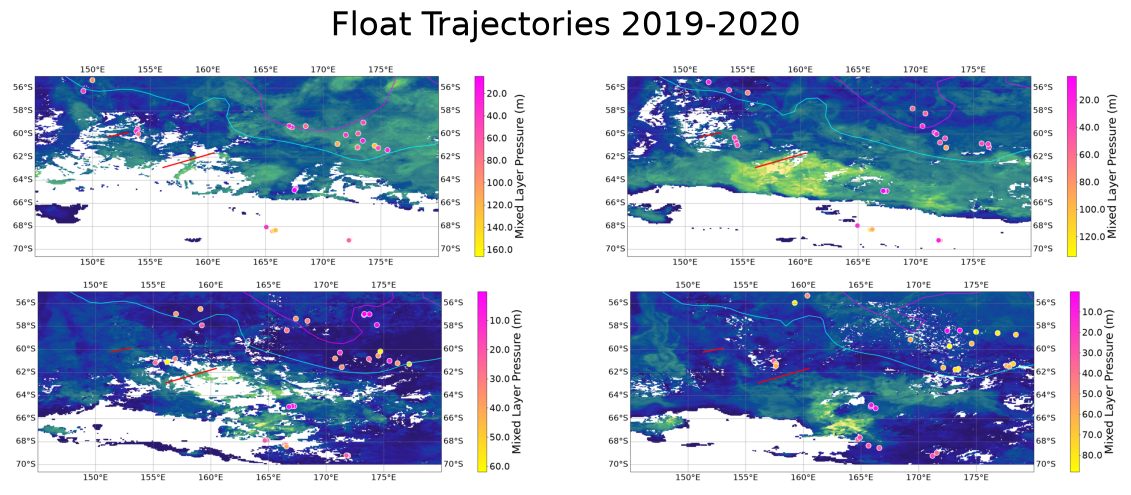

In [100]:
import matplotlib.image as mpimg

# 1. Define your file names (ensure these exist in your folder)
image_files = ['/Users/lilah/Documents/IBIS_Project/Figures_Summer/2019-11-01_2019-12-01_final_fig_traj_mld.png', '/Users/lilah/Documents/IBIS_Project/Figures_Summer/2019-12-01_2020-01-01_final_fig_traj_mld.png', '/Users/lilah/Documents/IBIS_Project/Figures_Summer/2020-01-01_2020-02-01_final_fig_traj_mld.png', '/Users/lilah/Documents/IBIS_Project/Figures_Summer/2020-02-01_2020-03-01_final_fig_traj_mld.png']

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle('Float Trajectories 2019-2020', fontsize=24)

# 3. Loop through axes and images to display them
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")  # Hide the x/y numbers and ticks

# 4. Save the combined grid and show it
plt.tight_layout()  # Adjusts spacing automatically
plt.savefig(
    "/Users/lilah/Documents/IBIS_Project/Figures_Summer/all4traj.png",
    bbox_inches="tight", dpi=400, transparent=True
)
plt.show()

## updated Antarctica CHLA map for background of poster

In [127]:
def chla_plot_matchups(shortname, tspan, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(-180, 180), lat=slice(-32,-90))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)

        # PLOTTING DATA ------------------------------------------------
        
        #assign projection type
        crs = ccrs.PlateCarree()
        crs0 = ccrs.SouthPolarStereo(central_longitude=120)
        theta = np.linspace(0, 2*np.pi, 100)
        map_circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        #colorscale range (same for Argo and satellite)
        norm = LogNorm(vmin=0.1, vmax=6)
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs,norm=norm) 

        #chla colorbar
        cbar = fig.colorbar(plot, fraction=0.02, pad=0.03)
        cbar.set_label('Log Chl-a (mg m$^{-3}$)', fontsize = 24)
        cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        cbar.ax.tick_params(labelsize=18)

           # Define start and end points for KR1 and KR2
        start_lon1, start_lat1 = 151.33, -60.24
        end_lon1, end_lat1 = 153.08, -59.89
        start_lon2, start_lat2 = 156.12, -62.91
        end_lon2, end_lat2 = 160.48, -61.66
        
        # Plot diagonal line on map
        ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=1.5, linestyle='-', transform=crs)
        ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=1.5, linestyle='-', transform=crs)

        cutoff = pd.Timestamp("2024-12-31", tz="UTC")

        if time_start <= cutoff:            # Adding fronts to plot
            # front_ds = xr.open_dataset('/raid/walkersl/SO_Argo/Data/SO_front_fields_zones_monthly.nc')
            front_ds = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data_Summer/SO_front_fields_zones_monthly.nc')

            front_field_levels = {
                'STF': ('theta_100', 11.0),
                'SAF': ('theta_400', 5.0),
                'PF':  ('theta_min', 2.0),
            }

            def get_front_contours(front_ds, timestep, front_field_levels):
                """Return dict of {front_name: list of (N,2) lon/lat vertex arrays} for one timestep."""
                contours = {}
                for front, (varname, level) in front_field_levels.items():
                    field = front_ds[varname].sel(time=timestep, method='nearest')
                    gen = contourpy.contour_generator(x=field['lon'].values, y=field['lat'].values, z=field.values)
                    contours[front] = gen.lines(level)
                return contours

            time = front_ds['time']
            timestep = time.isel(time=i).values
            timestep = pd.to_datetime(timestep, utc=True)
            time_label = timestep.strftime("%Y-%m-%d")

            front_contours = get_front_contours(front_ds, time_label, front_field_levels)

            front_colors = {'STF': 'yellow', 'SAF': 'fuchsia', 'PF': 'cyan'}
            for front, lines in front_contours.items():
                for verts in lines:
                    ax.plot(verts[:,0], verts[:,1], color=front_colors[front],
                         transform=ccrs.PlateCarree(), linewidth=1.5)

        #study region box
        lon_lim=[150,180]
        lat_lim=[-68,-58]
        rect = mpatches.Rectangle(
            (lon_lim[0], lat_lim[0]),
            lon_lim[1] - lon_lim[0],
            lat_lim[1] - lat_lim[0],
            transform=ccrs.PlateCarree(),
            facecolor='none', edgecolor='red', linewidth=2, linestyle='-'
        )
        ax.add_patch(rect)

        coast_50m = cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor='darkgray')
        ax.add_feature(coast_50m)
        ax.set_boundary(map_circle, transform=ax.transAxes)
        ax.set_title('2019-2020 Surface Chlorophyll-a', fontsize = 34, pad = 20)

        fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/antarctica_map_{time_start}_{time_end}_surface_chla_{shortname}.png', bbox_inches='tight', transparent=True)
        plt.close()


chla_plot_matchups(shortname="VIIRSN_L3m_CHL",
                   tspan=("2019-11-01", "2020-03-30"),  
                   clouds=None, 
                   granulename="*.SNWI.*4*") 



/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 346.15it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.81s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 9986.44it/s]
100%|██████████| 1/1 [00:24<00:00, 24.63s/it]


## Trajectory

In [116]:
df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
df_subset = df[df['season'].isin(['2019-2020'])]
df_surface = (df_subset.dropna(subset=['CHLA_ADJUSTED']).sort_values(['WMOID','CYCLE_NUMBER','PRES_ADJUSTED']).groupby(['WMOID','CYCLE_NUMBER']).first().reset_index())

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_5704/2320243116.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')


In [133]:
# version edited by Lilah on 8/13/26
def chla_plot_matchups(shortname, tspan, bbox, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        bounding_box=bbox,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(150, 180), lat=slice(-58,-75))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)

        
        # PLOTTING DATA ------------------------------------------------
        
        #assign projection type
        crs0 = ccrs.PlateCarree()
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        #colorscale range (same for Argo and satellite)
        norm = LogNorm(vmin=0.1, vmax=6)
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs0,norm=norm) 

        #chla colorbar
        cbar = fig.colorbar(plot, fraction=0.02, pad=15)
        cbar.set_label('Log Chl-a (mg m$^{-3}$)', fontsize =30)
        cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        cbar.ax.tick_params(labelsize=35)

        # NEW TRAJECTORY PLOT
        sc = ax.scatter(df_surface['LONGITUDE'], df_surface['LATITUDE'], c=df_surface['CHLA'], cmap='viridis', norm=LogNorm(vmin=0.04, vmax=5),linewidth=0.2, s=100, edgecolor='white')
        
        # # plot points for each WMOID - point color = chla, edgecolor = WMOID
        # for wmo in wmoids:
        #     df_wmo = df_chla[df_chla['WMOID'] == wmo]
        
        #     sc = ax.scatter(df_wmo['LONGITUDE'],df_wmo['LATITUDE'],c=df_wmo['CHLA_ADJUSTED'],cmap=color,norm=norm,
        #                s=150,transform=ccrs.PlateCarree(),edgecolor=wmoid_colors[wmo],linewidth=1,label=str(wmo))
        
        #create legend info
        # handles = [
        #     mlines.Line2D([], [], color=wmoid_colors[wmo], marker='o', linestyle='None', markersize=10, label=str(wmo))
        #     for wmo in wmoids]

        # if len(wmoids) == 0:
        #     print('no floats')
        # else:
        #     # create legend
        #     ax.legend(handles=handles,title="WMOID",loc='lower center',ncol=len(wmoids),
        #         bbox_to_anchor=(0.5, -0.15),fontsize=10,title_fontsize=12)

        # plot cycle number labels (optional, it kind of gets in the way
        # for _, row in df_chla.iterrows():
        #     ax.text(row['LONGITUDE'] + 0.2, row['LATITUDE'] + 0.4,   # add an offset to the label marker
        #             str(int(row['CYCLE_NUMBER'])),transform=ccrs.PlateCarree(),fontsize=9,
        #             fontweight='bold', color='white', ha='center')

        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

        gl.xlabel_style = {'size': 25, 'color': 'black'}
        gl.ylabel_style = {'size': 25, 'color': 'black'}

        # Define start and end points for KR1 and KR2
        start_lon1, start_lat1 = 151.33, -60.24
        end_lon1, end_lat1 = 153.08, -59.89
        start_lon2, start_lat2 = 156.12, -62.91
        end_lon2, end_lat2 = 160.48, -61.66
        
        # Plot diagonal line on map
        ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())
        ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())

        cutoff = pd.Timestamp("2024-12-31", tz="UTC")

        if time_start <= cutoff:            # Adding fronts to plot
            # front_ds = xr.open_dataset('/raid/walkersl/SO_Argo/Data/SO_front_fields_zones_monthly.nc')
            front_ds = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data_Summer/SO_front_fields_zones_monthly.nc')

            front_field_levels = {
                'STF': ('theta_100', 11.0),
                'SAF': ('theta_400', 5.0),
                'PF':  ('theta_min', 2.0),
            }

            def get_front_contours(front_ds, timestep, front_field_levels):
                """Return dict of {front_name: list of (N,2) lon/lat vertex arrays} for one timestep."""
                contours = {}
                for front, (varname, level) in front_field_levels.items():
                    field = front_ds[varname].sel(time=timestep, method='nearest')
                    gen = contourpy.contour_generator(x=field['lon'].values, y=field['lat'].values, z=field.values)
                    contours[front] = gen.lines(level)
                return contours

            time = front_ds['time']
            timestep = time.isel(time=i).values
            timestep = pd.to_datetime(timestep, utc=True)
            time_label = timestep.strftime("%Y-%m-%d")

            front_contours = get_front_contours(front_ds, time_label, front_field_levels)

            front_colors = {'STF': 'green', 'SAF': 'fuchsia', 'PF': 'cyan'}
            for front, lines in front_contours.items():
                for verts in lines:
                    ax.plot(verts[:,0], verts[:,1], color=front_colors[front],
                         transform=ccrs.PlateCarree(), linewidth=1.5)

        ax.set_extent([150, 180, -68, -58])
        
        # create string for the title label
        title_start = time_start.strftime("%Y-%m-%d")
        title_end = time_end.strftime("%Y-%m-%d")
        
        ax.set_title('Float Trajectories 2019-2020', fontsize = 45)       
        
        #save figure
        # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_{shortname}_float_matchup.png',
        #         bbox_inches='tight')
        fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/final_fig_traj_2019-2020.png', bbox_inches='tight', transparent=True, dpi =400)
        plt.close()

# 8-day composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-12-30"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.8D.*4*")

# monthly composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-01-31"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.MO.*4*")

# monthly composites with VIIRS
chla_plot_matchups(shortname="VIIRSN_L3m_CHL",
                   tspan=("2025-09-01", "2026-04-30"), 
                   bbox=(150, -68, 180, -58), 
                   clouds=None, 
                   granulename="*.SNWI.*4*")
 


/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 969.11it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:02<00:00,  2.11s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 5497.12it/s]
  0%|          | 0/1 [00:30<?, ?it/s]


RuntimeError: FT_Render_Glyph (ft2font_wrapper.cpp line 1934) failed with error 0x62: raster overflow

## Create gifs

MovieWriter imagemagick unavailable; using Pillow instead.


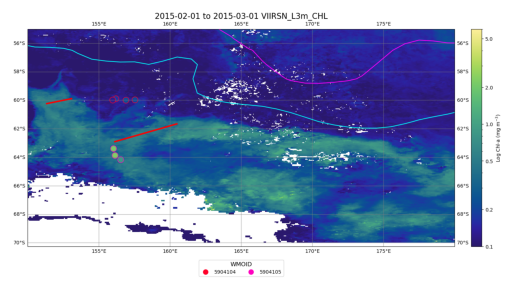

In [16]:
tools.create_gif(filepath='/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/2014-2015/',
                 savepath='/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/2014-09_2015-05_surface_chla_VIIRSN_L3m_CHL_float_matchup.gif')

## TEST FUNCTIONS

In [1]:
# version edited by Lilah on 8/13/26
def chla_plot_matchups(shortname, tspan, bbox, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        bounding_box=bbox,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(130, 180), lat=slice(-55,-70))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)

        # subset the Argo profile data
        df_sub = df_new[(df_new["LATITUDE"]<=-55) & (df_new["LATITUDE"]>=-70) & (df_new["LONGITUDE"]>=130) & (df_new["LONGITUDE"]<=180)]
        df_subset = df_sub[(df_sub["DATE"] >= time_start) & (df_sub["DATE"] <= time_end)]
        # extract nearest surface chla point
        df_chla = (df_subset.dropna(subset=['CHLA_ADJUSTED']).sort_values(['WMOID','CYCLE_NUMBER','PRES_ADJUSTED']).groupby(['WMOID','CYCLE_NUMBER']).first().reset_index())

        # extract WMOIDs for this time period
        wmoids = df_chla['WMOID'].unique()
        # create a colormap for the WMOID legend
        cmap = plt.get_cmap('gist_rainbow', len(wmoids))
        wmoid_colors = {wmo: cmap(i) for i, wmo in enumerate(wmoids)}

        # PLOTTING DATA ------------------------------------------------
        
        #assign projection type
        crs0 = ccrs.PlateCarree()
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        #colorscale range (same for Argo and satellite)
        norm = LogNorm(vmin=0.1, vmax=6)
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs0,norm=norm) 

        #chla colorbar
        cbar = fig.colorbar(plot, fraction=0.02, pad=0.03)
        cbar.set_label('Log Chl-a (mg m$^{-3}$)')
        cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        
        # plot points for each WMOID - point color = chla, edgecolor = WMOID
        for wmo in wmoids:
            df_wmo = df_chla[df_chla['WMOID'] == wmo]
        
            sc = ax.scatter(df_wmo['LONGITUDE'],df_wmo['LATITUDE'],c=df_wmo['CHLA_ADJUSTED'],cmap=color,norm=norm,
                       s=150,transform=ccrs.PlateCarree(),edgecolor=wmoid_colors[wmo],linewidth=1,label=str(wmo))

            print(np.unique(wmo))
        
        #create legend info
        handles = [
            mlines.Line2D([], [], color=wmoid_colors[wmo], marker='o', linestyle='None', markersize=10, label=str(wmo))
            for wmo in wmoids]

        if len(wmoids) == 0:
            print('no floats')
        else:
            # create legend
            ax.legend(handles=handles,title="WMOID",loc='lower center',ncol=len(wmoids),
                bbox_to_anchor=(0.5, -0.15),fontsize=10,title_fontsize=12)

        # plot cycle number labels (optional, it kind of gets in the way
        # for _, row in df_chla.iterrows():
        #     ax.text(row['LONGITUDE'] + 0.2, row['LATITUDE'] + 0.4,   # add an offset to the label marker
        #             str(int(row['CYCLE_NUMBER'])),transform=ccrs.PlateCarree(),fontsize=9,
        #             fontweight='bold', color='white', ha='center')

        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

        # Define start and end points for KR1 and KR2
        start_lon1, start_lat1 = 151.33, -60.24
        end_lon1, end_lat1 = 153.08, -59.89
        start_lon2, start_lat2 = 156.12, -62.91
        end_lon2, end_lat2 = 160.48, -61.66
        
        # Plot diagonal line on map
        ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())
        ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())

        cutoff = pd.Timestamp("2024-12-31", tz="UTC")

        if time_start <= cutoff:            # Adding fronts to plot
            # front_ds = xr.open_dataset('/raid/walkersl/SO_Argo/Data/SO_front_fields_zones_monthly.nc')
            front_ds = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data_Summer/SO_front_fields_zones_monthly.nc')

            front_field_levels = {
                'STF': ('theta_100', 11.0),
                'SAF': ('theta_400', 5.0),
                'PF':  ('theta_min', 2.0),
            }

            def get_front_contours(front_ds, timestep, front_field_levels):
                """Return dict of {front_name: list of (N,2) lon/lat vertex arrays} for one timestep."""
                contours = {}
                for front, (varname, level) in front_field_levels.items():
                    field = front_ds[varname].sel(time=timestep, method='nearest')
                    gen = contourpy.contour_generator(x=field['lon'].values, y=field['lat'].values, z=field.values)
                    contours[front] = gen.lines(level)
                return contours

            time = front_ds['time']
            timestep = time.isel(time=i).values
            timestep = pd.to_datetime(timestep, utc=True)
            time_label = timestep.strftime("%Y-%m-%d")

            front_contours = get_front_contours(front_ds, time_label, front_field_levels)

            front_colors = {'STF': 'green', 'SAF': 'fuchsia', 'PF': 'cyan'}
            for front, lines in front_contours.items():
                for verts in lines:
                    ax.plot(verts[:,0], verts[:,1], color=front_colors[front],
                         transform=ccrs.PlateCarree(), linewidth=1.5)

        ax.set_extent([130, 180, -70, -55])
        
        # create string for the title label
        title_start = time_start.strftime("%Y-%m-%d")
        title_end = time_end.strftime("%Y-%m-%d")
        
        ax.set_title(title_start+' to '+title_end+' '+shortname, fontsize=16)        
        
        #save figure
        # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_{shortname}_float_matchup.png',
        #         bbox_inches='tight')
        fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_{shortname}_float_matchup.png', bbox_inches='tight')
        plt.close()

# 8-day composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-12-30"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.8D.*4*")

# monthly composites with MODIS
# chla_plot_matchups(shortname="MODISA_L3m_CHL",
#                    tspan=("2015-01-01", "2015-01-31"), 
#                    bbox=(130, -78, 180, -50), 
#                    clouds=None, 
#                    granulename="*.MO.*4*")

# monthly composites with VIIRS
chla_plot_matchups(shortname="VIIRSN_L3m_CHL",
                   tspan=("2025-09-01", "2026-04-30"), 
                   bbox=(130, -78, 180, -50), 
                   clouds=None, 
                   granulename="*.MO.*4*")



NameError: name 'earthaccess' is not defined

## Old version in case I screw it up

In [12]:
# version edited by Stevie on 7/23/26
def chla_plot_matchups(shortname, tspan, bbox, clouds, granulename):

    # getting data files
    results = earthaccess.search_data(
        short_name=shortname,
        temporal=tspan,
        bounding_box=bbox,
        granule_name=granulename)  # 8-day for MODIS | Resolution: 0p1deg or 4 (for 4km) (want 4 for 4km)

    #open results (outside of the loop because you don't have to repeat this every time)
    paths = earthaccess.open(results)

    for i in tqdm(range(len(paths))):

        #open the granule and subset data to aar region
        ds = xr.open_dataset(paths[i],decode_times=False)
        data = ds['chlor_a'].sel(lon=slice(150, 180), lat=slice(-55,-70))

        # extract the start and end times, convert to datetime64 format
        time_start = getattr(ds, "time_coverage_start")
        time_end = getattr(ds, "time_coverage_end")
        time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
        time_end = pd.to_datetime(time_end, utc=True)
        
        # ^^ HINT: time_start and time_end are what you'll want to use for subsetting the Argo csv file to the correct date range
        # this is where you'll want to subset the Argo profile data
       
        # PLOTTING DATA ------------------------------------------------
        #assign projection type
        crs0 = ccrs.PlateCarree()
       
        #create figure object
        fig = plt.figure(figsize = (20,8))
    
        #add panel
        ax = fig.add_subplot(111, projection = crs0)
    
        #Colormap specification
        color = cmocean.cm.haline
        # plot satellite data
        plot = ax.pcolormesh(data['lon'],data['lat'],data,cmap=color,
                     transform=crs0,norm=LogNorm(vmin=0.1, vmax=6)) 

        #add plotting the argo data here
      
        cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
        cbar.set_label('Log Chl-a (mg m$^{-3}$)')
        cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
        cbar.formatter = FormatStrFormatter("%.1f")
        cbar.update_ticks()
        # cbar.ax.tick_params(labelsize=tick_size)
        # cbar.set_label('Chla', size=axis_size)
        gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                              linewidth=1, color='gray', alpha=0.6, linestyle='-')

        # Define start and end points for KR1 and KR2
        start_lon1, start_lat1 = 151.33, -60.24
        end_lon1, end_lat1 = 153.08, -59.89
        start_lon2, start_lat2 = 156.12, -62.91
        end_lon2, end_lat2 = 160.48, -61.66
        
        # Plot diagonal line on map
        ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())
        ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=3, linestyle='-', transform=ccrs.PlateCarree())


        # create string for the title label
        title_start = time_start.strftime("%Y-%m-%d")
        title_end = time_end.strftime("%Y-%m-%d")
        
        ax.set_title('MODIS '+title_start+' to '+title_end, fontsize=16)        
        
        #save figure
        # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_MODIS_float_matchup.png',
                # bbox_inches='tight')
        fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/satellite_float_matchups/chla/{title_start}_{title_end}_surface_chla_MODIS_float_matchup.png',
                bbox_inches='tight')
        plt.close()
   
chla_plot_matchups(shortname="MODISA_L3m_CHL",
                   tspan=("2015-01-01", "2015-01-31"), 
                   bbox=(150, -78, 180, -50), 
                   clouds=None, 
                   granulename="*.8D.*4*")


/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 491.47it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  2.31it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 42153.81it/s]
100%|██████████| 4/4 [00:13<00:00,  3.26s/it]


In [29]:
results = earthaccess.search_data(
        short_name="MODISA_L3m_CHL",
                   temporal=("2015-01-01", "2015-01-31"), 
                   bounding_box=(150, -78, 180, -50), 
                   granule_name="*.8D.*4*") 

paths = earthaccess.open(results)

ds = xr.open_dataset(paths[0],decode_times=False)
data = ds['chlor_a'].sel(lon=slice(150, 180), lat=slice(-55,-70))

time_start = getattr(ds, "time_coverage_start")
time_end = getattr(ds, "time_coverage_end")
time_start = pd.to_datetime(time_start, utc=True) # everything should be in UTC, but adding this just in case
time_end = pd.to_datetime(time_end, utc=True)

# time_start = pd.Series(time_start) # everything should be in UTC, but adding this just in case
# time_end = pd.Series(time_end)
df_sub = df_new[(df_new["LATITUDE"]<=-55) & (df_new["LATITUDE"]>=-70) & (df_new["LONGITUDE"]>=150) & (df_new["LONGITUDE"]<=180)]
df_subset = df_sub[(df_sub["DATE"] >= time_start) & (df_sub["DATE"] <= time_end)]


/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 1004.74it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  2.28it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 18098.40it/s]
